# Stock Market Prediction And Forecasting Using Stacked LSTM

In [1]:
import pandas as pd
import yfinance as yf
df = yf.download('AAPL',start='2024-01-01',end='2025-01-01')
# df = pd.read_csv('/content/AAPL_Montly_updates.csv')
df.head()

/tmp/ipykernel_427/2489806299.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL',start='2024-01-01',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562195,186.330858,181.831782,185.055288,82488700
2024-01-03,182.187759,183.799520,181.376930,182.158096,58414500
2024-01-04,179.873901,181.040686,178.855431,180.111205,71983600
2024-01-05,179.152100,180.714417,178.153410,179.953046,62379700
2024-01-08,183.483093,183.522654,179.468538,180.051930,59144500


In [2]:
df.shape

(252, 5)

In [3]:
df.reset_index()['Close']
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562195,186.330858,181.831782,185.055288,82488700
2024-01-03,182.187759,183.799520,181.376930,182.158096,58414500
2024-01-04,179.873901,181.040686,178.855431,180.111205,71983600
2024-01-05,179.152100,180.714417,178.153410,179.953046,62379700
2024-01-08,183.483093,183.522654,179.468538,180.051930,59144500
...,...,...,...,...,...
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100


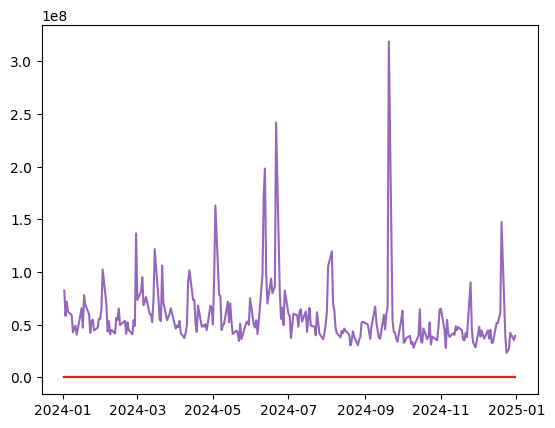

In [4]:
import matplotlib.pyplot as plt
plt.plot(df)

# LSTM are sensitive to the scale of the data. so we apply MinMax scaler

In [5]:
import numpy as np

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df=scaler.fit_transform(np.array(df).reshape(-1,1))

In [7]:
df

array([[6.62472849e-08],
       [7.49352033e-08],
       [6.08173417e-08],
       ...,
       [2.67967986e-07],
       [2.77353273e-07],
       [1.23887819e-01]])

# Spliting dataset into training and test split

In [8]:
training_size = int(len(df)*0.65)
test_size = len(df) - training_size
train_data, test_data = df[0:training_size,:], df[training_size:len(df),:1]


In [9]:
training_size,test_size

(819, 441)

In [10]:
train_data

array([[6.62472849e-08],
       [7.49352033e-08],
       [6.08173417e-08],
       [7.09325330e-08],
       [2.58844626e-01],
       [6.19343799e-08],
       [6.69919994e-08],
       [5.93900409e-08],
       [6.18412989e-08],
       [1.83301072e-01],
       [5.46736169e-08],
       [5.83349264e-08],
       [5.14777122e-08],
       [5.54182644e-08],
       [2.25880183e-01],
       [5.24086416e-08],
       [5.73111100e-08],
       [4.92748059e-08],
       [5.49219692e-08],
       [1.95743658e-01],
       [6.59990684e-08],
       [6.61232079e-08],
       [5.34016076e-08],
       [5.52322628e-08],
       [1.85591773e-01],
       [6.46958361e-08],
       [6.47268473e-08],
       [5.72180178e-08],
       [6.09103865e-08],
       [1.34434771e-01],
       [6.79538210e-08],
       [6.86053877e-08],
       [6.09103962e-08],
       [6.22446353e-08],
       [1.46833112e-01],
       [6.60921974e-08],
       [7.06223428e-08],
       [5.99796284e-08],
       [6.90398717e-08],
       [1.54161786e-01],


In [11]:
import numpy as np
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=3):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return np.array(dataX), np.array(dataY)

In [12]:

# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [13]:
print(X_train.shape), print(y_train.shape)

(718, 100)
(718,)


(None, None)

In [14]:
print(X_test.shape), print(ytest.shape)

(340, 100)
(340,)


(None, None)

In [15]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [16]:
# Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [17]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=50,batch_size=64,verbose=1)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - loss: 0.0080 - val_loss: 0.0037
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 0.0081 - val_loss: 0.0036
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - loss: 0.0080 - val_loss: 0.0039
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - loss: 0.0080 - val_loss: 0.0036
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 305ms/step - loss: 0.0080 - val_loss: 0.0036
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - loss: 0.0080 - val_loss: 0.0036
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 0.0079 - val_loss: 0.0037
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - loss: 0.0079 - val_loss: 0.0037
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - loss: 0.0079 - val_loss: 0.0035
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - loss: 0.0078 - val_loss: 0.0040
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - loss: 0.0079 - val_loss: 0.0035
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step

In [21]:
import tensorflow as tf

In [22]:
# Let's Do the prediiction and chek performance
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [23]:
# Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [24]:
# Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

28642031.857888076